In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dulieuxettuyendaihoc.csv', header=0)
# rename columns TOANLOGICPHANTICH thanh logic, GIAIQUYETVANDE thanh ungxu
df.rename(columns={'TOANLOGICPHANTICH':'LOGIC', 'GIAIQUYETVANDE':'UNGXU','DINHHUONGNGHENGHIEP':'DINHHUONG'}, inplace=True)
df.head()

,MSSV,T1,T2,T3,T4,T5,T6,GT,DT,KV,NGONNGU,LOGIC,UNGXU,KT,NGAYTHI,DINHHUONG
0,SV001,7.2,8.4,7.4,7.2,7.4,6.9,F,NaN,2NT,3.25,3.25,4.50,A1,12/7/2018,No
1,SV002,5.4,6.3,4.3,4.9,3.0,4.0,M,NaN,1,6.00,4.00,3.50,C,12/7/2018,Yes
2,SV003,5.6,5.0,2.8,6.1,4.8,5.7,M,NaN,1,5.00,6.75,4.00,C,12/7/2018,No
3,SV004,6.6,5.1,5.9,4.1,6.1,7.4,M,NaN,1,4.25,4.25,5.25,D1,12/7/2018,No
4,SV005,6.0,5.4,7.6,4.4,6.8,8.0,M,NaN,2NT,4.25,4.50,5.00,A,12/7/2018,No


In [ ]:
# Machine learning 
''' 
Dẫn nhập machine learning - Dựa trên dữ liệu lịch sử (Historical data) để xây dựng mô hình (Model) - Input đi qua Model (mô hình toán học) sẽ tính toán cho ra Output  
Các bài toán phổ biến 
1. Dự báo (Prediction) 
2. Phân loại (Classification) 
3. Gom cụm (Clustering) 
4. Luật kết hợp (Association rules) 
 
Các phương pháp phổ biến 
1. supervised 
2. un-supervised 
3. semi-supervised learning 
 
Quy trình xây dựng ứng dụng Machine Learning 
'''

In [ ]:
''' 
Dẫn nhập hồi quy tuyến tính 
Ứng dụng trong bài toán Prediction 
 
Bài toán 1: Hãy dự báo điểm T6 dựa trên T5 
input: T5 
Output T6 
T6 = f(T5) -> T6 = Ao + A1.T5 + epsilon 
'''

In [3]:
df[['T5', 'T6']].head(5) 

,T5,T6
0,7.4,6.9
1,3.0,4.0
2,4.8,5.7
3,6.1,7.4
4,6.8,8.0


In [4]:
df[['T5', 'T6']].corr()

,T5,T6
T5,1.000000,0.778683
T6,0.778683,1.000000


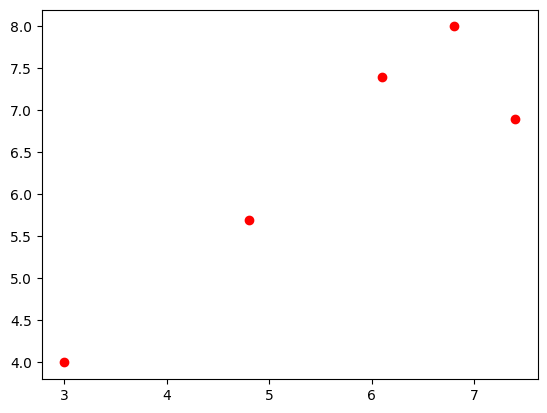

In [5]:
plt.plot(df[['T5']][0:5], df[['T6']][0:5], 'ro')
plt.show()

In [ ]:
''' 
Lý thuyết về hồi quy tuyến tính 
1. Phương pháp giải 
2. Các Phương pháp giải tối ưu chi phí tính toán 
3. DLS tối ưu sai số 
''' 

In [ ]:
# Bài toán 2: Hãy dự báo điểm thi đánh giá năng lực phần LOGIC dựa trên điểm trung 
# bình toán học kì 1 và học kì 2 năm lớp 12

In [ ]:
''' 
Input: T5 T6 
Output: LOGIC 
LOGIC = f(T5,T6) = Ao + A1.T5 + A2.T6 + epsilon 
 
Xây dựng mô hình trong Machine Learning 
Bước 1: Xác định bài toán 
B2: Xác định input và output 
B3: Xác định mô hình xử lý 
B4: Chia tập dữ liệu ra làm 2 phần: training và testing theo tỉ lệ 90% và 10% 
B5: Chạy mô hình 
B6: Đánh giá mô hình 
B7: Triển khai mô hình 
'''

In [6]:
# Tap du lieu
x = df[['T5', 'T6']]. values
y = df[['LOGIC']].values
# Chia tap du lieu
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=5)

# Xay dung mo hinh
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(x_train, y_train)
# He so tu do
print(model.intercept_)

print(model.coef_)


[2.68763106]
[[-0.11189321  0.3331366 ]]


In [7]:
pd.DataFrame(x_test).to_csv('input_test.csv')

In [8]:
pd.DataFrame(y_test).to_csv('output_test.csv')

In [9]:
from sklearn import metrics

y_test_pred = model.predict(x_test)

In [10]:
pd.DataFrame(y_test_pred).to_csv('output_test_pred.csv')

In [11]:
import numpy as np
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_test_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_test_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))
print('Scored:', model.score(x_test, y_test))

Mean Absolute Error: 0.7739518570284657
Mean Squared Error: 0.8285004273228378
Root Mean Squared Error: 0.9102199884219406
Scored: -0.06473950499320513


In [ ]:
''' 
Homework: Sử dụng độ đo đánh giá mô hình RMSE trên tập train và test. 
Hãy trả lời câu hỏi sau: - Nếu kết quả rmse trên tập train > rmse trên tập test thì mô hình có ý nghĩa là gì - Tương tự cho trường hợp bằng nhau và bé hơn 
# overfit, underfit 
''' 

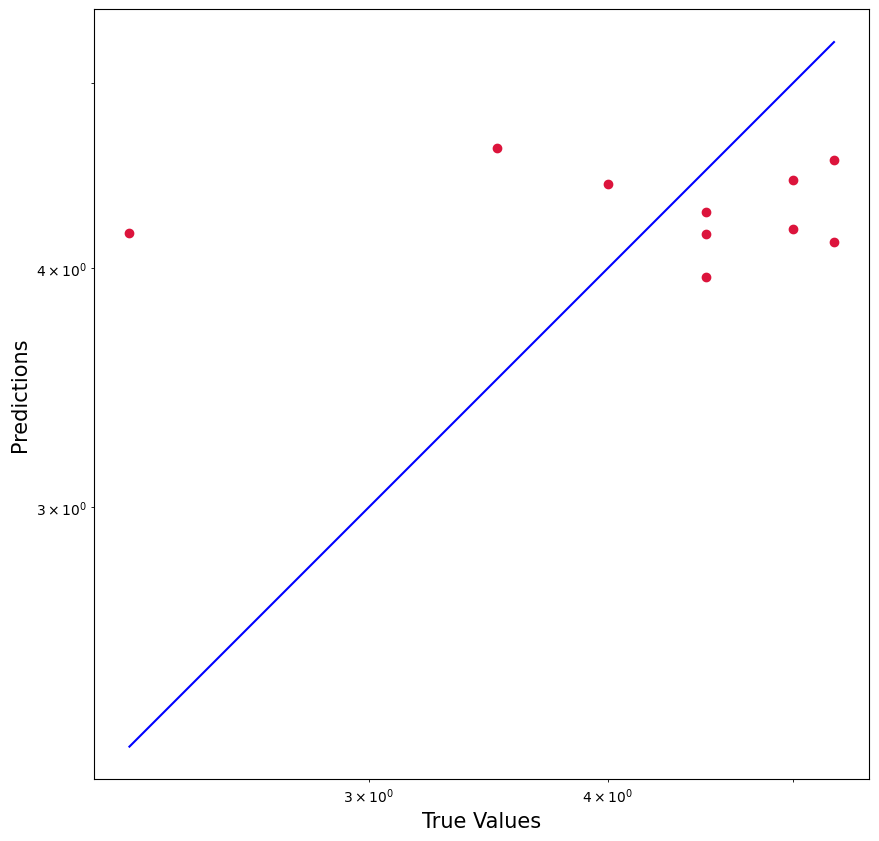

In [12]:
# Truc quan hoa du lieu
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_test_pred,c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(y_test), max(y_test_pred))
p2 = min(min(y_test), min(y_test_pred))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

In [13]:
import pickle
pickle.dump(model, open('model_linear_regression.sav', 'wb'))

In [14]:
loaded_model = pickle.load(open('model_linear_regression.sav', 'rb'))
vT5 = float(input('Nhap diem hoc ki 1 nam lop 12: '))
vT6 = float(input('Nhap diem hoc ki 2 nam lop 12: '))
predicted_vLogic = loaded_model.predict([[vT5, vT6]])
print('Du bao diem Logic: ', predicted_vLogic)

Du bao diem Logic:  [[4.348228]]
